# Martingale CDF Plot

Reproduces Figure 1: predicted CDFs using different LLMs with MP uncertainty visualized in blue.

**Input**: one `martingale_results.npz` per model, produced by `tools/martingale_property.py`.

**Output path structure** (from `_build_work_dir` in `martingale_property.py`):
```
<work_dir>/<config_folder>/martingale_check/martingale_results.npz
```

For example, if you ran:
```bash
python tools/martingale_property.py --config configs/obqa_gpt4o/obqa_gpt4o.yaml -w data/results_mp
```
the result file is at `data/results_mp/obqa_gpt4o/martingale_check/martingale_results.npz`.

In [43]:
# ── Configuration ────────────────────────────────────────────────────────────
# Edit MODELS to match your result files.
# Each entry: (display_name, path_to_martingale_results.npz)

MODELS = [
    ("GPT 4o Split = All",          "/Users/alicansahin/Desktop/martingale_results/obqa_gpt40/split_all/martingale_results.npz"),
]

# Seeds to aggregate over (None = use all seeds found in the file)
SEEDS = None

# x-axis limits for the logit-probability axis (None = auto-scale from data)
XLIM = None

# Output figure path (None = do not save, just show)
SAVE_PATH = "figures/martingale_cdfs.pdf"

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [49]:
# ── Helper functions ──────────────────────────────────────────────────────────

def logit_clipped(p: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Logit transform with clipping to avoid ±inf."""
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def ecdf(values: np.ndarray):
    """Empirical CDF. Returns (x_sorted, cumulative_fraction).

    Prepends (x[0], 0) so the curve visually starts at y=0.
    """
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    x = np.concatenate([[x[0]], x])
    y = np.concatenate([[0.0], y])
    return x, y


def load_and_aggregate(npz_path: str, seeds=None):
    """
    Load martingale_results.npz and concatenate across seeds.

    Returns
    -------
    distributions : (N_total, K+1, C)  float32
    true_labels   : (N_total,)          int32
    K             : int
    """
    data = np.load(npz_path, allow_pickle=True)
    seed_keys = list(data.keys()) if seeds is None else [str(s) for s in seeds]

    all_distributions = []
    all_true_labels   = []
    K_value = None

    for key in seed_keys:
        entry = data[key].item()          # dict stored as 0-d object array
        all_distributions.append(entry["distributions"])   # (N, K+1, C)
        all_true_labels.append(entry["true_labels"])        # (N,)
        k = int(entry["K"])
        if K_value is not None and k != K_value:
            raise ValueError(f"Seeds have different K values: {K_value} vs {k}")
        K_value = k

    return (
        np.concatenate(all_distributions, axis=0),
        np.concatenate(all_true_labels,   axis=0),
        K_value,
    )


def plot_model_cdfs(ax, distributions: np.ndarray, true_labels: np.ndarray, K: int, title: str = ""):
    """
    Plot martingale CDF uncertainty for a single model onto `ax`.

    Blue lines     — empirical CDF of logit(p_correct) at each iteration k=1..K
    Orange solid   — Mean CDF (average distribution over k=1..K)
    Red dashed     — Initial CDF (k=0)
    Green dash-dot — True CDF: logistic distribution centered at logit(accuracy),
                     representing the ideal calibration target.
    """
    N = distributions.shape[0]
    idx = np.arange(N)

    # ── Blue: CDF for each iteration k = 1 .. K ──────────────────────────────
    for k in range(1, K + 1):
        p_k = distributions[idx, k, true_labels]          # (N,)
        x_k, y_k = ecdf(logit_clipped(p_k))
        ax.plot(x_k, y_k, color="royalblue", alpha=0.25, linewidth=0.7)

    # ── Orange: Mean CDF (Martingale) ─────────────────────────────────────────
    # Mean predicted probability for the correct class, averaged over k=1..K
    p_iter = distributions[idx[:, None], np.arange(1, K + 1)[None, :], true_labels[:, None]]
    # shape: (N, K)  — p(correct | history_k) for each question and step
    p_mean = p_iter.mean(axis=1)                          # (N,)
    x_mean, y_mean = ecdf(logit_clipped(p_mean))
    ax.plot(x_mean, y_mean, color="orange", linewidth=2.0, zorder=4,
            label="Mean CDF (Martingale)")

    # ── Red dashed: Initial CDF (k=0) ─────────────────────────────────────────
    p0 = distributions[idx, 0, true_labels]               # (N,)
    x0, y0 = ecdf(logit_clipped(p0))
    ax.plot(x0, y0, color="red", linewidth=2.0, linestyle="--", zorder=5,
            label="Initial CDF")

    # ── Green dash-dot: True CDF ──────────────────────────────────────────────
    # Logistic distribution centered at logit(accuracy at k=0).
    # A perfectly calibrated model with accuracy `acc` should assign
    # logit-probabilities following logistic(logit(acc), 1). If the blue cloud
    # does not overlap this curve, the model's uncertainty is miscalibrated
    # relative to its actual performance.
    acc = np.clip((distributions[:, 0, :].argmax(-1) == true_labels).mean(), 1e-6, 1 - 1e-6)
    center = np.log(acc / (1.0 - acc))                    # logit(accuracy)
    x_true = np.linspace(-20, 20, 2000)
    y_true = 1.0 / (1.0 + np.exp(-(x_true - center)))    # logistic CDF
    ax.plot(x_true, y_true, color="green", linewidth=2.0, linestyle="-.", zorder=6,
            label="True CDF")

    acc_pct = acc * 100
    ax.set_title(f"{title}\n(acc={acc_pct:.1f}%) \n(K={K})", fontsize=11)
    if XLIM is not None:
        ax.set_xlim(XLIM)
    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("CDF Value")
    ax.grid(True, alpha=0.3)

GPT 4o Split = All: N=5957, K=5, C=4
Saved to figures/martingale_cdfs.pdf


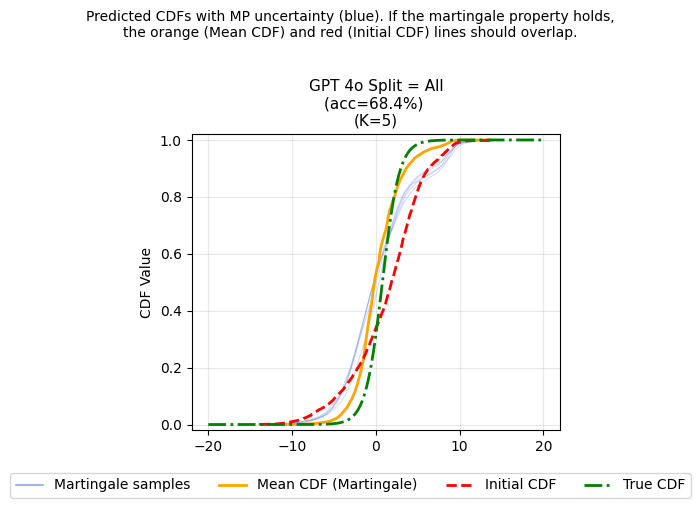

In [50]:
# ── Build figure ──────────────────────────────────────────────────────────────

n_models = len(MODELS)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4.5), sharey=True)

if n_models == 1:
    axes = [axes]

for ax, (model_name, npz_path) in zip(axes, MODELS):
    npz_path = Path(npz_path)

    distributions, true_labels, K = load_and_aggregate(str(npz_path), seeds=SEEDS)
    print(f"{model_name}: N={distributions.shape[0]}, K={K}, C={distributions.shape[2]}")
    if not npz_path.exists():
        ax.text(0.5, 0.5, f"File not found:\n{npz_path}",
                ha="center", va="center", transform=ax.transAxes, color="red", fontsize=9)
        ax.set_title(f'{model_name}', fontsize=11)
        continue

    plot_model_cdfs(ax, distributions, true_labels, K, title=model_name)

# Shared legend below all subplots
handles, labels = axes[0].get_legend_handles_labels()
# Add a proxy for the blue iteration lines
import matplotlib.lines as mlines
blue_proxy = mlines.Line2D([], [], color="royalblue", alpha=0.6, linewidth=1.2)
handles = [blue_proxy] + handles
labels  = ["Martingale samples"] + labels

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
    fontsize=10,
)

fig.suptitle(
    "Predicted CDFs with MP uncertainty (blue). If the martingale property holds,\n"
    "the orange (Mean CDF) and red (Initial CDF) lines should overlap.",
    y=1.02, fontsize=10,
)

plt.tight_layout()

if SAVE_PATH is not None:
    out = Path(SAVE_PATH)
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches="tight", dpi=150)
    print(f"Saved to {out}")
plt.show()